# Web Scraping 

In this lab, we will be building various web scrapers for Flight-Report.com.

The website hosts reviews of flights. 

You'll be able to search for reviews of flights specifying `Airports` and `Airlines`.

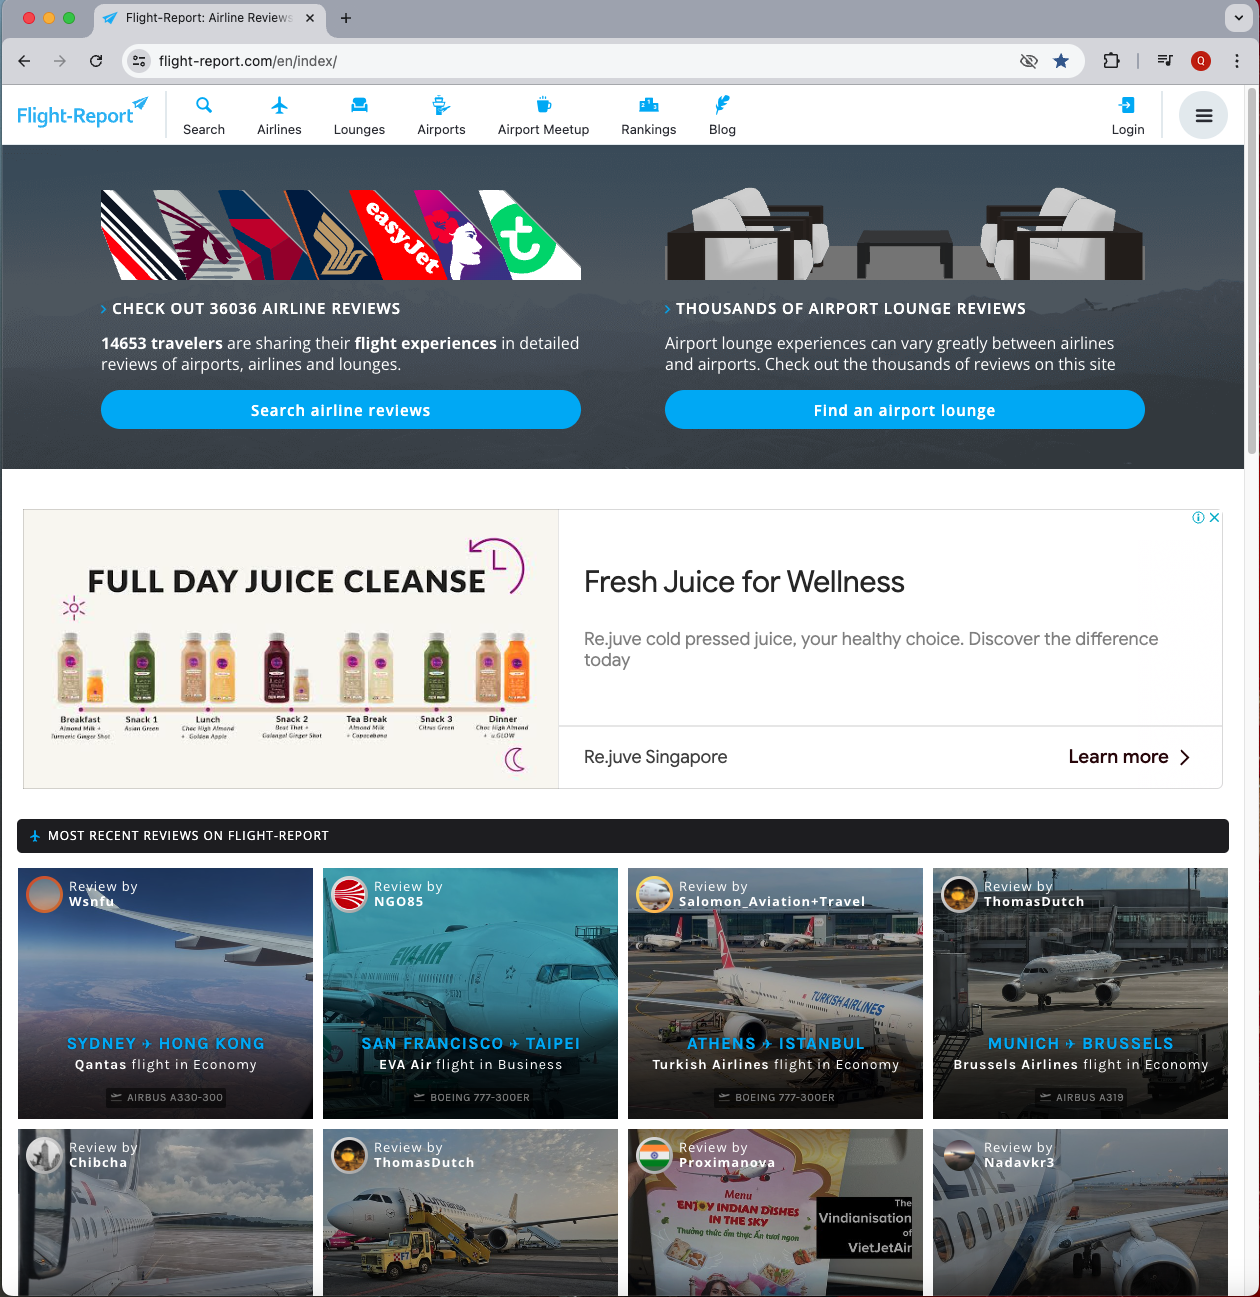

In [ ]:
# get a list of URLs of the Airlines
# get a list of URLs of the reviews of Flights of these Airlines
# write functions
# cycle thru URL, run the functions
# consolidate data in dataframes

In [1]:
#load necessary libraries
from bs4 import BeautifulSoup
import requests
import datetime
import re
import pandas as pd
import numpy as np
import time


We will first define a number of functions to extract various parts of the site and attempt to combine them together.

# Setting up caching mechanism

As we will be using `requests.get()` to download the pages quite a lot, so it is important to setup some caching mechanism to avoid repeated downloading of the same url. For this lab, we will use a very simple caching mechanism by storing the html in a form of a dictionary in memory that maps a url to html. In real life, we would prefer storing the html as physical files.

In [2]:
#execute this cell again to clear the cache
simple_cache = {}
simple_cache


{}

In [3]:
#this method takes in a url 
#and returns the html of the url
#subsequently, instead of calling 
#requests.get(), we should use this 
#function to get the html instead
def get_cached_html(url):
    if url in simple_cache:
        return simple_cache[url]
    else:
        user_agent = {"User-agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36"}
        page = requests.get(url, headers=user_agent)
        simple_cache[url] = page.content
        #print(simple_cache[url])
        return simple_cache[url]
    

#### ❓Q1.
Complete this function (`get_airlines(alphabet, minReviews)`) which takes in an `alphabet` and the `minReviews` value and extract all the links of the airlines with a minimum number of reviews.
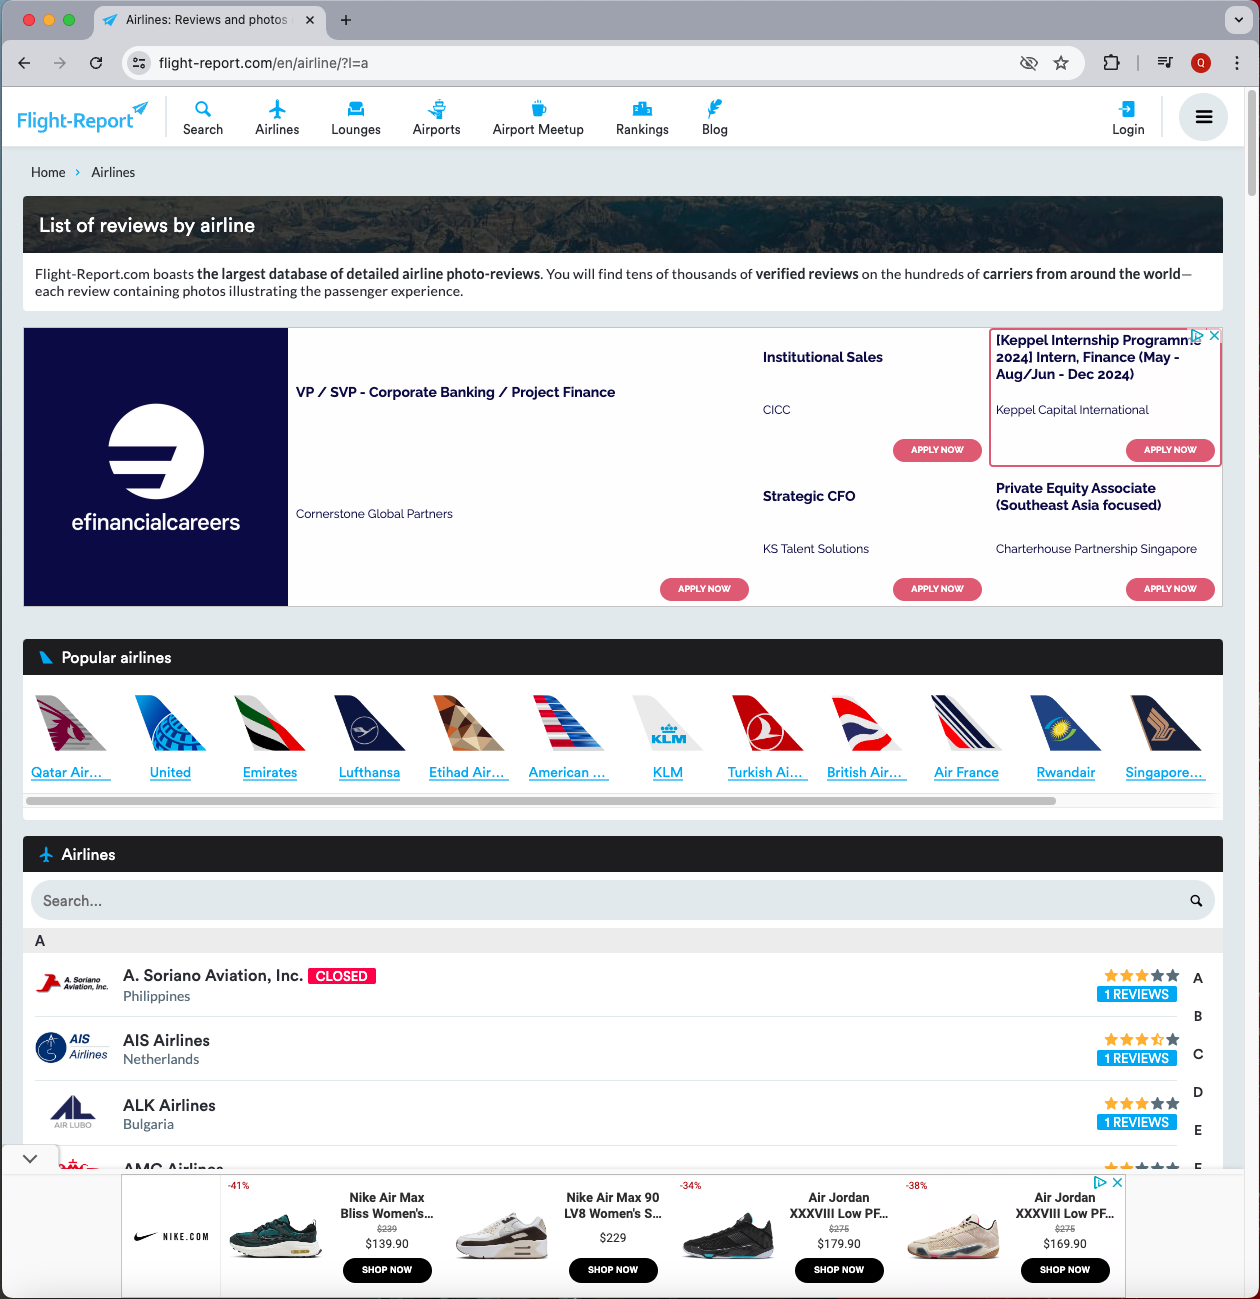

In [ ]:
#TODO
def get_airlines(alphabet, minReviews=100):

    url = f"https://flight-report.com/en/airline/?l={alphabet}"
    html = get_cached_html(url)
    soup = BeautifulSoup(html, 'html.parser')

    link_elements = soup.select("div[class='airline'] a[class='reviews']")
    urls = ["https://www.flight-report.com" + link_element["href"] for link_element in link_elements]
    urls = pd.Series(urls)
          
    review_elements = soup.select("div[class='airline'] a[class='reviews'] span")
    reviewsCounts = [review_element.get_text(strip=True) for review_element in review_elements]
    reviewsCounts = pd.Series(reviewsCounts).astype(int) 
    
    urls = urls[reviewsCounts >= minReviews]

    return urls.tolist()


### Get List of URLs of Airlines with Minimum 300 reviews

In [ ]:
#List of A to Z
alphabets = [chr(i) for i in range(ord('a'), ord('z')+1)]
alphabets


In [ ]:
airlines_urls = []

for alphabet in alphabets:
    airlines_list = get_airlines(alphabet, minReviews=300)
    if len(airlines_list) > 0:
        airlines_urls.extend(airlines_list)
    print("{}.".format(alphabet), end="")
    
airlines_urls


#### ❓Q2.

Complete this function (`get_airline_details(url)`) which takes in an airline `url` and extract the following information in a Dictionary:
- Name of the Airline 
- IATA Code of the Airline
- Description of the Airline
- Overall Rating
- Average Cabin Crew Rating
- Average Meal and Snacks Rating
- Average Cabin and Seat Comfort Rating
- Average Entertainment/Wifi Rating

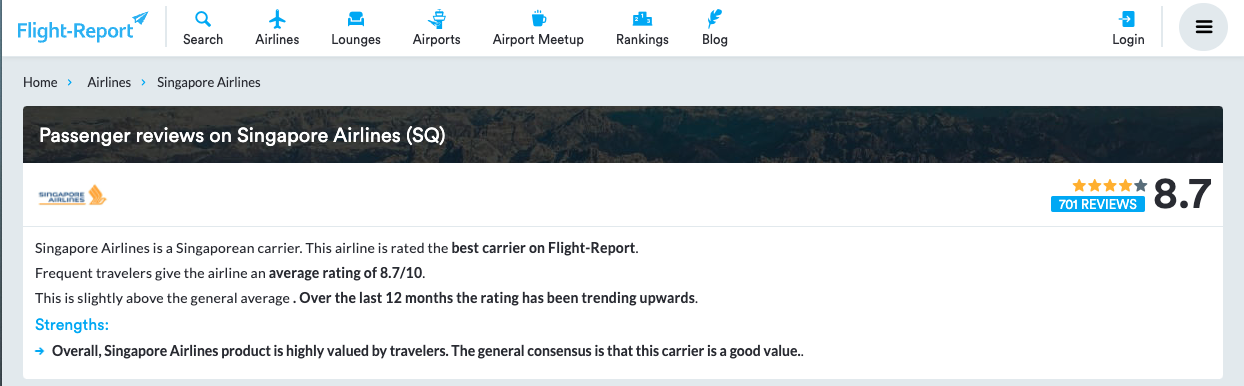
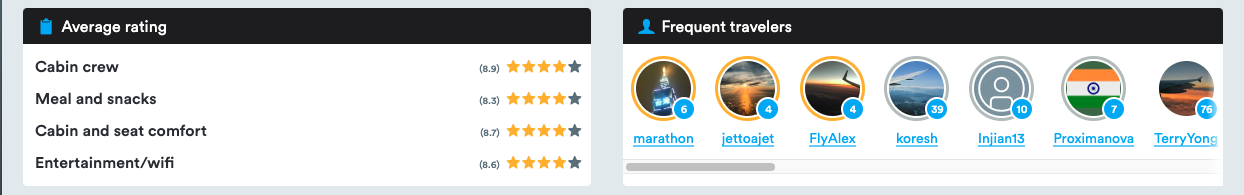

In [ ]:
#TODO
def get_airline_details(url):

    html = get_cached_html(url)
    soup = BeautifulSoup(html, 'html.parser')


    #extract name and IATA Code
    name_code = soup.select("h1 span")

    name = name_code[0].get_text(strip=True)
    code = name_code[1].get_text(strip=True)

    del name_code


    #extract description
    desc = soup.select("section[class='paper'] div p")
    desc = [desc_p.get_text(strip=True) for desc_p in desc]
    desc = " ".join(desc)

    #extract overall ratings
    ovrall = soup.select_one("div[class='big-rating'] span").get_text(strip=True)
    ovrall = float(ovrall)
    
    #extract sub-ratings
    subratings = soup.select("ul[class='ratings'] li")
    subratings = [subrating.get_text(strip=True) for subrating in subratings]

    crew = 0; meal = 0; seat = 0; wifi = 0

    for i in range(0, len(subratings)):

        if 'Cabin crew' in subratings[i]:
            crew = subratings[i].replace('Cabin crew', '')
            crew = float(crew)
            next 

        if "Meal and snacks" in subratings[i]:
            meal = subratings[i].replace('Meal and snacks', '')
            meal = float(meal)
            next 

        if "Cabin and seat comfort" in subratings[i]:
            seat = subratings[i].replace('Cabin and seat comfort', '')
            seat = float(seat)
            next 

        if "Entertainment/wifi" in subratings[i]:
            wifi = subratings[i].replace('Entertainment/wifi', '')
            wifi = float(wifi)
            next 

    
    #results
    results = {
        "Airline Name": name,
        "Airline IATA Code": code,
        "Description": desc,
        "Overall Rating": ovrall,
        "Average Cabin Crew Rating": crew,
        "Average Meal and Snacks Rating": meal,
        "Average Cabin and Seat Comfort Rating": seat,
        "Average Entertainment/Wifi Rating": wifi
    }
    
    return results


In [ ]:
airline = get_airline_details("https://flight-report.com/en/airline/4432/singapore-airlines/")
airline


#### ❓Q3.

Complete this function (`get_reviews_url(url, maxPages)`) which takes in an Airline `url` as well as integer `maxPages` and return a list of relevant Review URLs from a maximum number of pages.

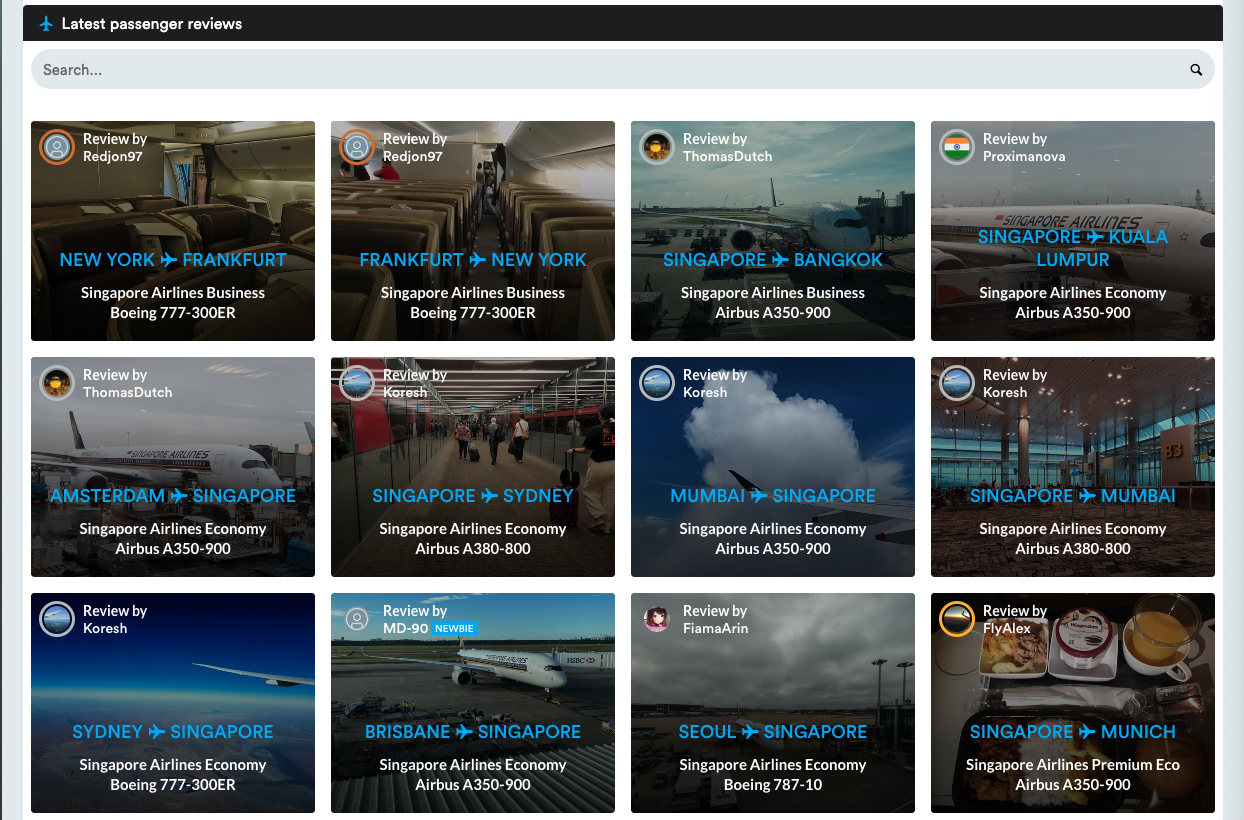
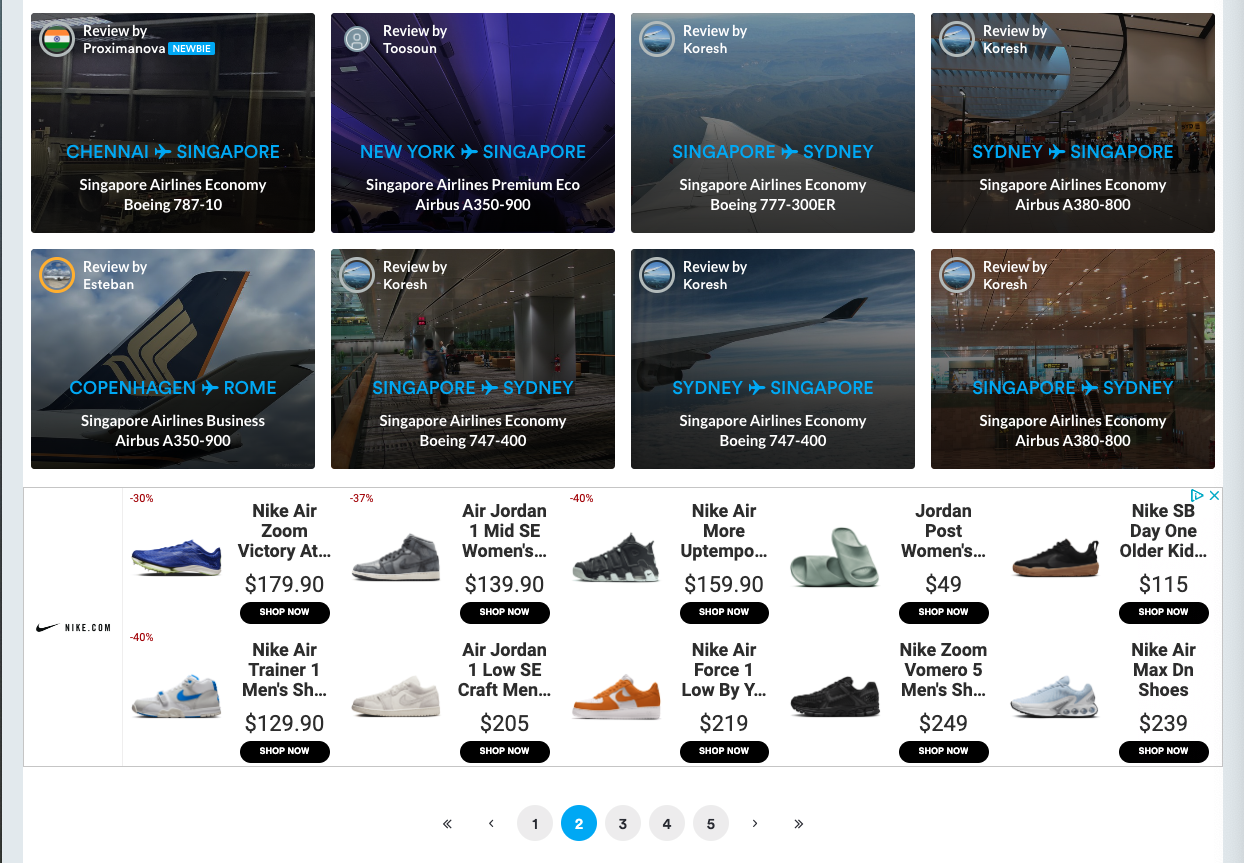

In [ ]:
#TODO
def get_reviews_url(url, maxPages=2):
    
    results = []
    
    for i in range(1, maxPages+1):
        page = f"{url}?page={i}"
        html = get_cached_html(page)
        soup = BeautifulSoup(html, "html.parser")

        reviews = soup.select("div[id='reports'] div[itemprop='itemListElement'] a:not(.avatar)")
        reviews_urls = ["https://www.flight-report.com" + review["href"] for review in reviews]

        if len(reviews_urls) == 0:
            break
        else:
            results.extend(reviews_urls)
            print("{}.".format(i), end="")
    
    print("---")
    return results


In [ ]:
sia_reviews = get_reviews_url("https://flight-report.com/en/airline/4432/singapore-airlines/", 5)
sia_reviews[0:10]


In [ ]:
len(sia_reviews)


#### ❓Q4.

Complete this function (`get_review_details(url)`) which takes in a Review `url` and extract details of the Review. This function should return a Dictionary with the following data. Each review should consist of the following columns:
- Name of Reviewer
- IATA Code of the Airline
- Name of Airline
- Flight Number
- Type of Aircraft
- Class of Seat
- Departure Date
- Flight Duration
- Departure Airport
- Arrival Airport
- Review Text
- Conclusion
- Airline Overall Rating


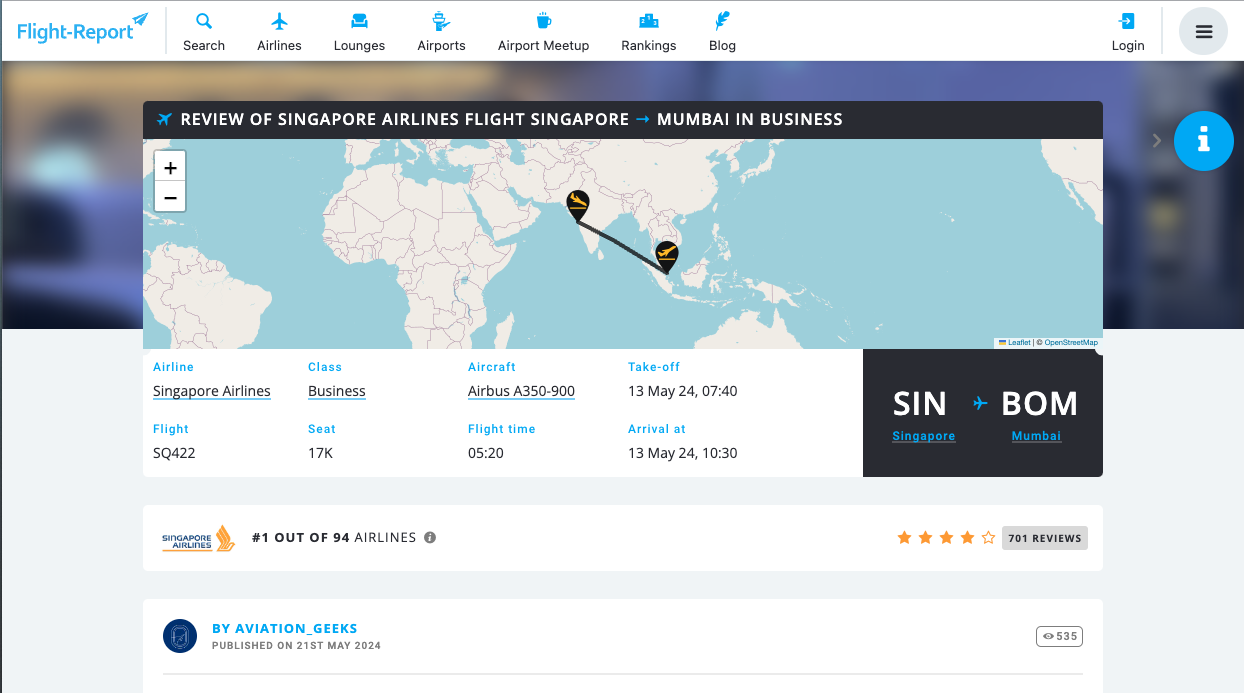
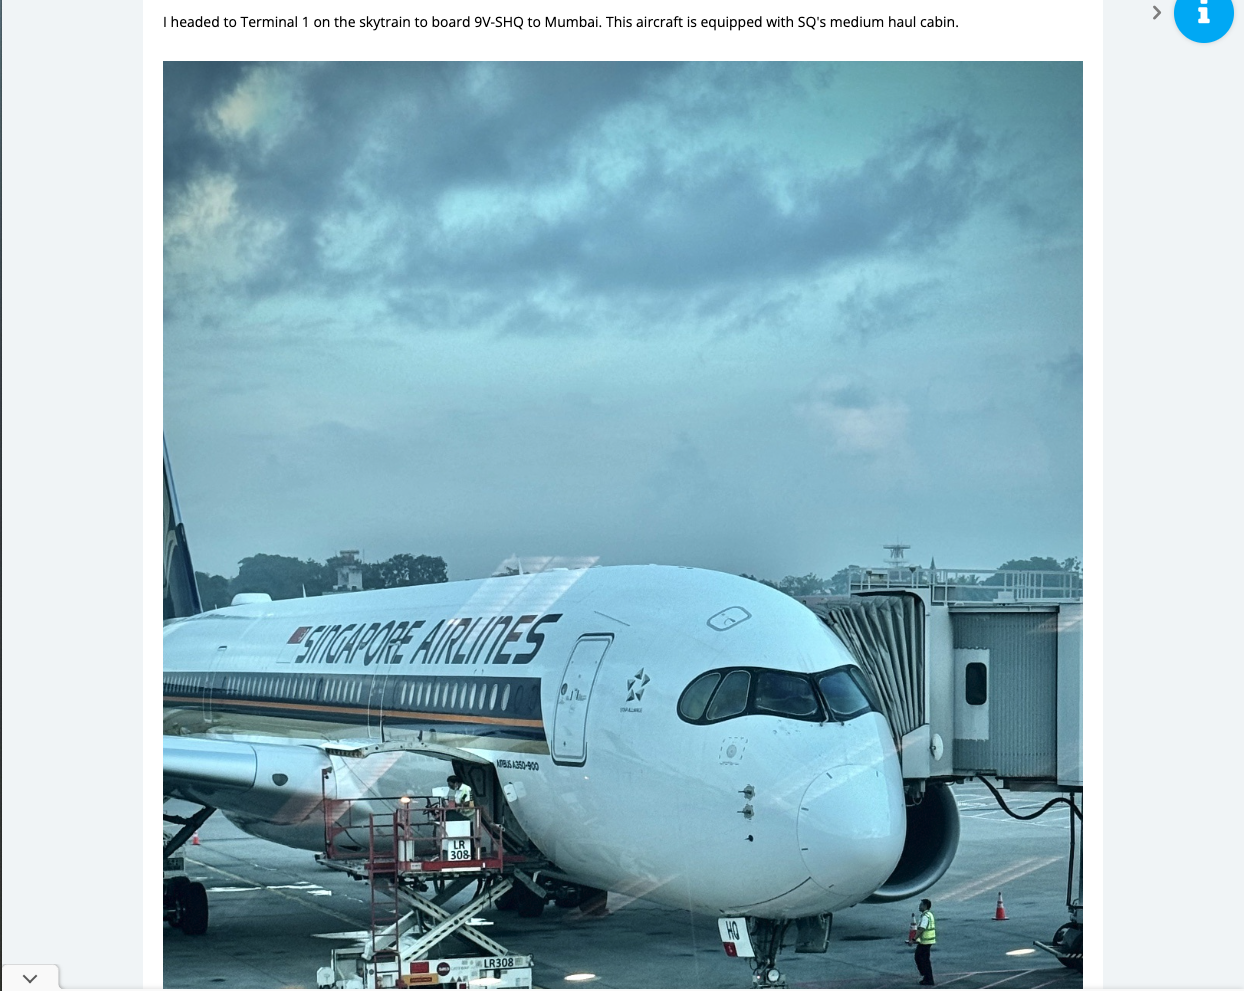
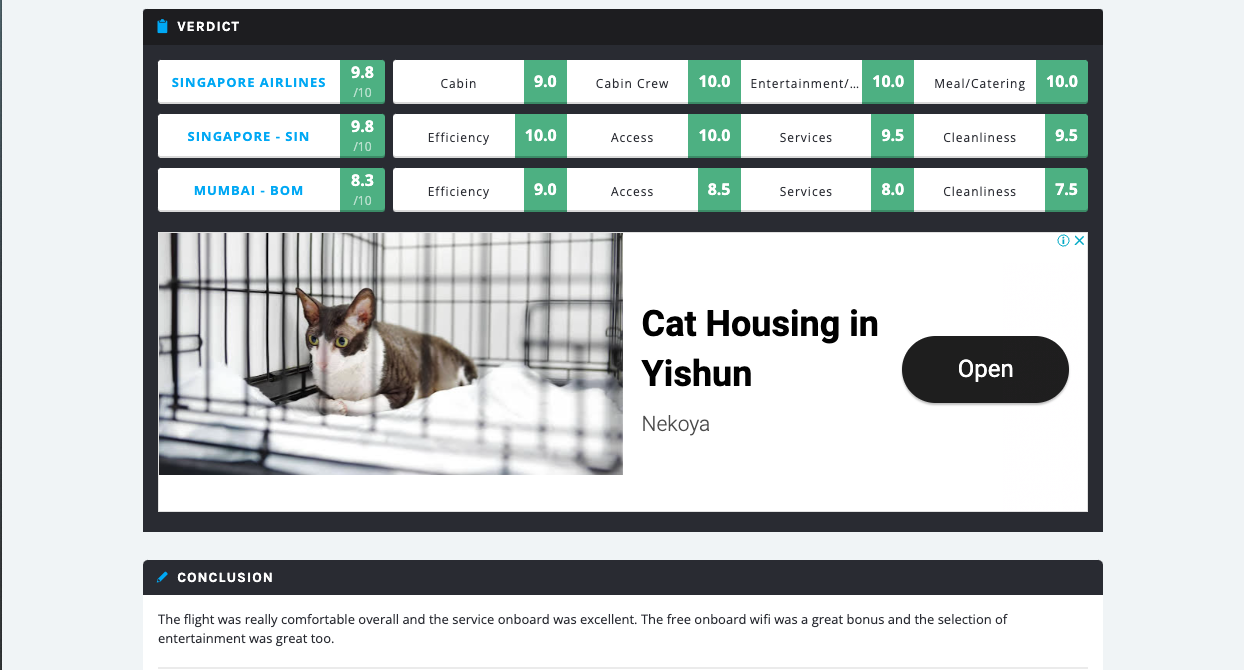

In [ ]:
#TODO
def get_review_details(url):
    
    html = get_cached_html(url)
    soup = BeautifulSoup(html, "html.parser")

    #extract name of reviewer
    name = soup.select_one("div[class='about'] span[itemprop='name']").get_text(strip=True)
    
    #extract IATA Code of airline
    iata = soup.select_one("div[class='airline-information'] h3 a span").get_text(strip=True)
    
    #extract name of airline
    airline = soup.select_one("div[class='airline-information'] h3 a").get_text(strip=True)
    airline = airline.replace(iata, "").replace("-", "").strip()
    
    #extract flight number
    flight = soup.select("div[id='report-data'] span[itemprop='flightNumber']")
    flight = flight[0].get_text(strip=True)
    
    #extract aircraft model and seat class
    info = soup.select("div[class='secondary-informations'] span")
    info = [info_p.get_text(strip=True) for info_p in info]
    
    aircraft = "NA"; seatclass = "NA";
    
    for i in range(0, len(info)):
    
        if 'Model' in info[i]:
            aircraft = info[i+1]
            next 
    
        if "Class" in info[i]:
            seatclass = info[i+1]
            next 
    
    #extract departure date
    departDate = soup.select_one("div[class='airline-information'] span[class='text-grey']").get_text(strip=True)
    departDate = departDate.replace("Flight taken on", "").strip()
    
    #extract flight duration
    duration = soup.select_one("div[class='flight-path'] span[class='duration']").get_text(strip=True)

    #extract departure airport
    departAP = soup.select_one("div[class='flight-path-component'] a[itemprop='departureAirport'] span").get_text(strip=True)
    
    #extract arrival airport
    arriveAP = soup.select_one("div[class='flight-path-component'] a[itemprop='arrivalAirport'] span").get_text(strip=True)

    #extract review text
    reviewtext = soup.select("div[id='main-report-content'] p")
    reviewtext = [reviewtext_p.get_text(strip=True) for reviewtext_p in reviewtext]
    reviewtext = " ".join(reviewtext)

    #extract conclusion
    conclusion = soup.select("section[id='conclusion'] p")
    conclusion = [conclusion_p.get_text(strip=True) for conclusion_p in conclusion]
    conclusion = " ".join(conclusion)
    
    #extract airline overall rating
    rating = soup.select("section[id='ratings'] h3 span")
    rating = float(rating[1].get_text(strip=True))

    results = {
        "Name of Reviewer": name,
        "IATA Code of Airline": iata,
        "Name of Airline": airline,
        "Flight Number": flight,
        "Type of Aircraft": aircraft,
        "Class of Seat": seatclass,
        "Departure Date": departDate,
        "Flight Duration": duration,
        "Departure Airport": departAP,
        "Arrival Airport": arriveAP,
        "Review Text": reviewtext, 
        "Conclusion": conclusion,
        "Airline Overall Rating": rating
    }

    return results


In [ ]:
sia_review = get_review_details(sia_reviews[0])
sia_review


#### ❓Q5.

Produce a Pandas Dataframe of Airline detail comprising Airlines with at least **500 Reviews** (using the `get_airlines()` and `get_airlines_details()` functions). 

To regulate the web scraping process, you should introduce some wait time (e.g. `time.sleep(0.5)` between scraping 2 pages to avoid getting banned by the site. 

Do you notice any potential error when running `get_airlines_details()`? If so, go back and refine the method.

In [ ]:
#TODO
airlines_urls = []

alphabets = [chr(i) for i in range(ord('a'), ord('z')+1)]
minimum_reviews = 500

for alphabet in alphabets:
    
    airlines_list = get_airlines(alphabet, minReviews=minimum_reviews)
    
    if len(airlines_list) > 0:
        airlines_urls.extend(airlines_list)
        
    print("{}.".format(alphabet), end="")
    
airlines_urls


In [ ]:
airlines_details = pd.DataFrame(
    columns=["Airline Name", "Airline IATA Code", "Description", "Overall Rating", 
             "Average Cabin Crew Rating",
             "Average Meal and Snacks Rating", 
             "Average Cabin and Seat Comfort Rating",
             "Average Entertainment/Wifi Rating"])

for url in airlines_urls:
    
    print(f"downloading {url}")
    
    airline_details = get_airline_details(url)
    airline_details = pd.DataFrame([airline_details])
    airlines_details = pd.concat([airlines_details, airline_details], ignore_index=True)

    del airline_details
    time.sleep(0.5)
    
airlines_details


#### ❓Q6.

Now try scraping the Reviews of the Airlines using `get_reviews_url()` and `get_review_details()`. Scrap a maximum of **1 page** from each Airline.

Again, remember to regulate the web scraping process by introducing some wait time (e.g. `time.sleep(0.5)` between scraping 2 pages. 

Do you notice any potential error when running `get_review_details()`? If so, go back and refine the method.

In [ ]:
#TODO
reviews_url = []

for url in airlines_urls:
    
    print(f"downloading {url}")
    
    results = get_reviews_url(url, 1)
    
    if len(results) > 0: 
        reviews_url.extend(results)

    time.sleep(0.5)
    

In [ ]:
reviews_url[0:10]


In [ ]:
len(reviews_url)


In [ ]:
reviews_details = pd.DataFrame(
    columns=["Name of Reviewer", "IATA Code of Airline", "Name of Airline", 
             "Flight Number", "Type of Aircraft", "Class of Seat", 
             "Departure Date", "Flight Duration",
             "Departure Airport", "Arrival Airport",  
             "Review Text", "Conclusion", 
             "Airline Overall Rating"])

import random
random.seed(123)
for url in random.choices(reviews_url, k=10):
    
    print(f"downloading {url}")

    review_details = get_review_details(url)
    review_details = pd.DataFrame([review_details])
    reviews_details = pd.concat([reviews_details, review_details], ignore_index=True)

    del review_details
    time.sleep(0.5)

reviews_details


============================================================